In [17]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import glob

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
import glob
import os
import pandas as pd

# Path to your 'DATASETS' folder in Google Drive
# Note: Adjust path if 'DATASETS' is inside a subfolder (e.g., 'My Drive/Projects/DATASETS')
folder_path = '/content/drive/MyDrive/DATASETS'

# Pattern to find all .csv files in the folder
csv_files = glob.glob(os.path.join(folder_path, '*.csv'))

print(f"Found {len(csv_files)} CSV files.")

# Read each CSV and combine them into one DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)

print(f"Combined DataFrame shape: {combined_df.shape}")

Found 50 CSV files.
Combined DataFrame shape: (204329, 2)


In [20]:
output_path = os.path.join(folder_path, 'combined_dataset.csv')
combined_df.to_csv(output_path, index=False)
print(f"Saved combined file to: {output_path}")

Saved combined file to: /content/drive/MyDrive/DATASETS/combined_dataset.csv


In [22]:
combined_df.columns

Index(['sale_time', 'purchaser_gender'], dtype='object')

In [23]:
combined_df.isnull().sum()

,0
sale_time,0
purchaser_gender,0


**Question1---   Plot daily sales for all 50 weeks.**

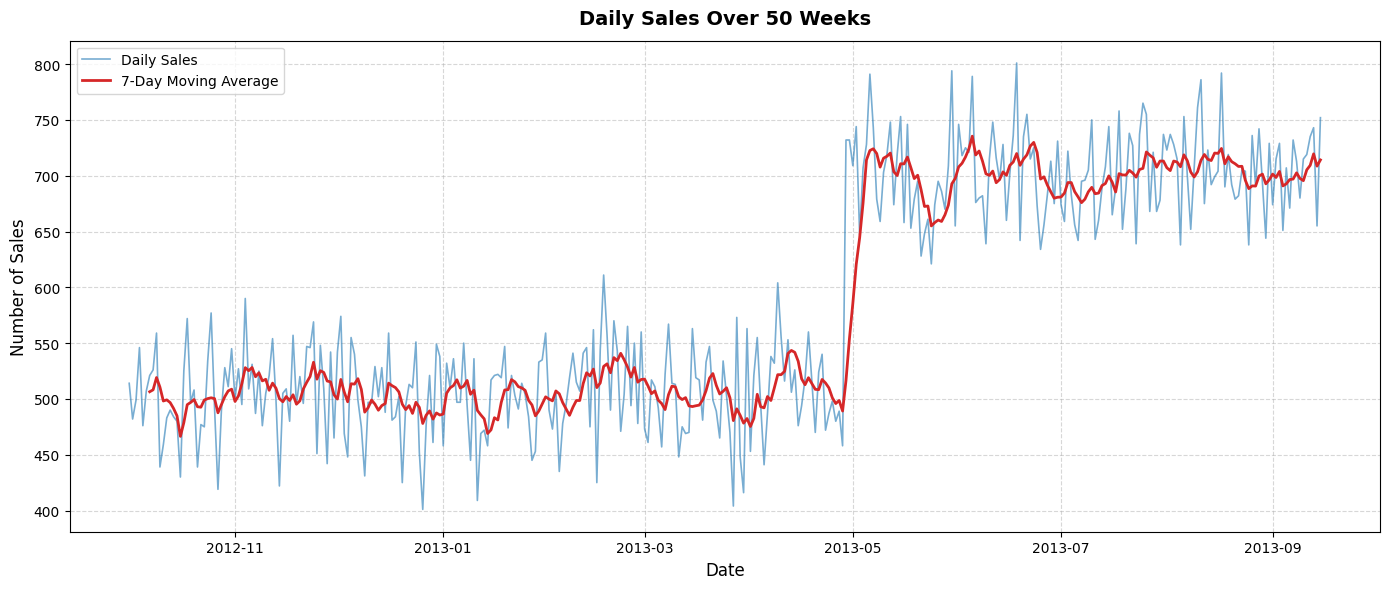

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('/content/combined_dataset.csv')

# 2. Convert timestamp column to datetime
df['sale_time'] = pd.to_datetime(df['sale_time'])

# 3. Aggregate daily sales count
# (If your file has a revenue/amount column, use .resample('D')['sale_amount'].sum() instead)
daily_sales = df.set_index('sale_time').resample('D').size()

# 4. Calculate 7-day rolling average to show the trend clearly
rolling_avg = daily_sales.rolling(window=7).mean()

# 5. Plot daily sales
plt.figure(figsize=(14, 6))

plt.plot(
    daily_sales.index,
    daily_sales.values,
    color='#1f77b4',
    alpha=0.6,
    linewidth=1.2,
    label='Daily Sales',
)
plt.plot(
    rolling_avg.index,
    rolling_avg.values,
    color='#d62728',
    linewidth=2,
    label='7-Day Moving Average',
)

# 6. Formatting and styling
plt.title(
    'Daily Sales Over 50 Weeks', fontsize=14, fontweight='bold', pad=12
)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()

# 7. Display the plot
plt.show()

**Question2 ---
It looks like there has been a sudden change in daily sales. What date did it occur?**

In [25]:
daily_sales_df = df.set_index('sale_time').resample('D').size().reset_index()
daily_sales_df.columns = ['date', 'num_sales']

# Compare number of sales difference with the previous day and find the biggest difference
# which should give the sudden change in the plot
daily_sales_df['prev_day_num_sales'] = [None] + daily_sales_df['num_sales'].to_list()[:-1]
daily_sales_df['difference_btw_prev_day'] = daily_sales_df['num_sales'] - daily_sales_df['prev_day_num_sales']

# Preview the dataframe
print(daily_sales_df.head())

# Find the row corresponding to the largest positive day-over-day jump
sudden_change_row = daily_sales_df.loc[daily_sales_df['difference_btw_prev_day'].idxmax()]

print("\nSudden change occurred on:")
print(f"Date: {sudden_change_row['date'].strftime('%Y-%m-%d')}")
print(f"Sales on previous day: {int(sudden_change_row['prev_day_num_sales'])}")
print(f"Sales on this day: {int(sudden_change_row['num_sales'])}")
print(f"Increase: +{int(sudden_change_row['difference_btw_prev_day'])} sales")

        date  num_sales  prev_day_num_sales  difference_btw_prev_day
0 2012-10-01        514                 NaN                      NaN
1 2012-10-02        482               514.0                    -32.0
2 2012-10-03        499               482.0                     17.0
3 2012-10-04        546               499.0                     47.0
4 2012-10-05        476               546.0                    -70.0

Sudden change occurred on:
Date: 2013-04-29
Sales on previous day: 458
Sales on this day: 732
Increase: +274 sales


**Question3 ----
Is the change in daily sales at the date you selected statistically significant? If so, what is the p-value?**

In [27]:
from scipy import stats
import pandas as pd

# Ensure 'date' is a datetime column and set it as the index
daily_sales_df['date'] = pd.to_datetime(daily_sales_df['date'])
daily_sales_df.set_index('date', inplace=True)

# Define the date at which the largest change in daily sales was observed
change_date = '2013-04-29'

# Split the dataset into two groups: one before the change date and one after (inclusive)
before = daily_sales_df[daily_sales_df.index < change_date]['num_sales']
after = daily_sales_df[daily_sales_df.index >= change_date]['num_sales']

# Perform a two-sample Welch’s t-test
t_stat, p_value = stats.ttest_ind(before, after, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: -45.943533193935615
p-value: 3.487246853115062e-138


**Question 4 ----
Does the data suggest that the change in daily sales is due to a shift in the proportion of male-vs-female customers? Please use plots to support your answer (a rigorous statistical analysis is not necessary).**

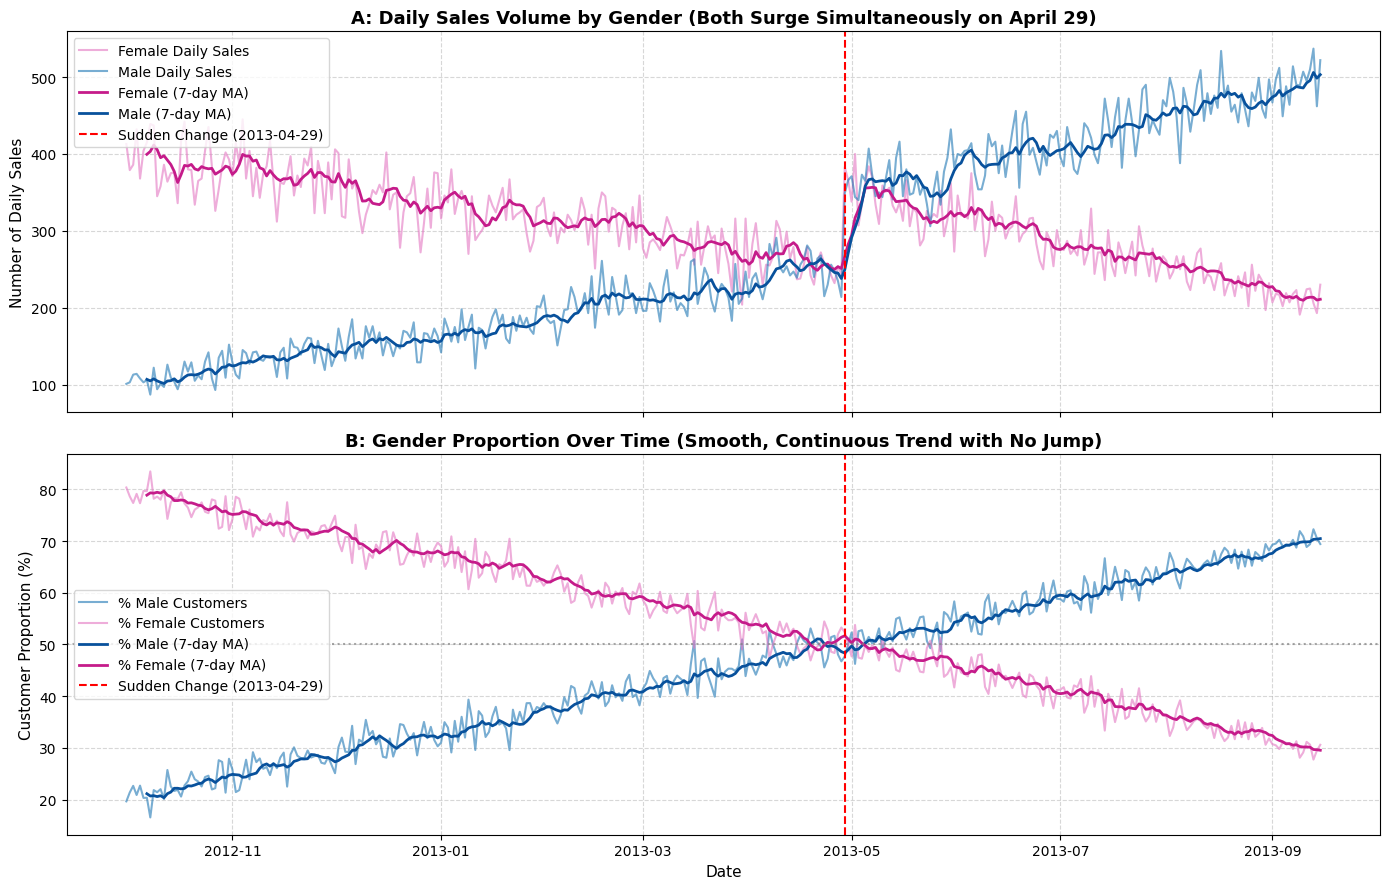

In [30]:
df['sale_time'] = pd.to_datetime(df['sale_time'])

# Aggregate daily sales by purchaser gender
gender_daily = (
    df.groupby([pd.Grouper(key='sale_time', freq='D'), 'purchaser_gender'])
    .size()
    .unstack(fill_value=0)
)
gender_daily['total'] = gender_daily['female'] + gender_daily['male']
gender_daily['female_pct'] = (
    gender_daily['female'] / gender_daily['total']
) * 100
gender_daily['male_pct'] = (gender_daily['male'] / gender_daily['total']) * 100

# Create diagnostic subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Plot 1: Daily sales volume by gender
ax1.plot(
    gender_daily.index,
    gender_daily['female'],
    color='#e377c2',
    alpha=0.6,
    label='Female Daily Sales',
)
ax1.plot(
    gender_daily.index,
    gender_daily['male'],
    color='#1f77b4',
    alpha=0.6,
    label='Male Daily Sales',
)
ax1.plot(
    gender_daily.index,
    gender_daily['female'].rolling(7).mean(),
    color='#c51b8a',
    linewidth=2,
    label='Female (7-day MA)',
)
ax1.plot(
    gender_daily.index,
    gender_daily['male'].rolling(7).mean(),
    color='#08519c',
    linewidth=2,
    label='Male (7-day MA)',
)
ax1.axvline(
    pd.to_datetime('2013-04-29'),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Sudden Change (2013-04-29)',
)
ax1.set_ylabel('Number of Daily Sales', fontsize=11)
ax1.set_title(
    'A: Daily Sales Volume by Gender (Both Surge Simultaneously on April 29)',
    fontsize=13,
    fontweight='bold',
)
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Customer proportions over time
ax2.plot(
    gender_daily.index,
    gender_daily['male_pct'],
    color='#1f77b4',
    alpha=0.6,
    label='% Male Customers',
)
ax2.plot(
    gender_daily.index,
    gender_daily['female_pct'],
    color='#e377c2',
    alpha=0.6,
    label='% Female Customers',
)
ax2.plot(
    gender_daily.index,
    gender_daily['male_pct'].rolling(7).mean(),
    color='#08519c',
    linewidth=2,
    label='% Male (7-day MA)',
)
ax2.plot(
    gender_daily.index,
    gender_daily['female_pct'].rolling(7).mean(),
    color='#c51b8a',
    linewidth=2,
    label='% Female (7-day MA)',
)
ax2.axvline(
    pd.to_datetime('2013-04-29'),
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Sudden Change (2013-04-29)',
)
ax2.axhline(50, color='gray', linestyle=':', alpha=0.7)
ax2.set_ylabel('Customer Proportion (%)', fontsize=11)
ax2.set_xlabel('Date', fontsize=11)
ax2.set_title(
    'B: Gender Proportion Over Time (Smooth, Continuous Trend with No Jump)',
    fontsize=13,
    fontweight='bold',
)
ax2.legend(loc='center left')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Question 5 ----
Assume a given day is divided into four dayparts: night (12:00AM - 6:00AM), morning (6:00AM to 12:00PM), afternoon (12:00PM to 6:00PM) and evening (6:00PM - 12:00AM). What is the percentage of sales in each daypart over all 50 weeks?**

In [32]:
# Extract sale hour to divide sales to the part of days
df['sale_hour'] = pd.to_datetime(df['sale_time']).dt.ceil('h').dt.hour

# Define a function to apply sale hour column to decide a part of day based on the mentioned logic
def assign_day_part(sale_hour):
    """Assign labels based on sale hour."""
    if sale_hour >= 6 and sale_hour < 12:
        return 'morning'
    if sale_hour >= 12 and sale_hour < 18:
        return 'afternoon'
    if sale_hour >= 18 and sale_hour < 24:
        return 'evening'
    if sale_hour >= 0 and sale_hour < 6:
        return 'night'

# Apply the defined function and create day_part column
df['day_part'] = df['sale_hour'].apply(assign_day_part)

# Drop unnecessary columns
df.drop(columns=['purchaser_gender', 'sale_hour', 'sale_time'], inplace=True)

# Calculate number of sales per day part
df_pct_sales = df.groupby(df.day_part).size().reset_index(name='day_part_num_sales')

# Calculate number of sales percentage per day part
df_pct_sales['day_part_sales_percentage'] = df_pct_sales['day_part_num_sales'] / df_pct_sales['day_part_num_sales'].sum()

print(df_pct_sales)

    day_part  day_part_num_sales  day_part_sales_percentage
0  afternoon               81159                   0.397198
1    evening               53523                   0.261945
2    morning               56080                   0.274459
3      night               13567                   0.066398
